# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Fathan Nabil Rahman
- **Email:** nblrhmn5@students.unnes.ac.id
- **ID Dicoding:** nabeelrr

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana tren jumlah order dan total revenue per bulan selama 2017–2018, dan pada bulan apa terjadi puncak penjualan tertinggi?
- **Pertanyaan 2:** Kategori produk mana yang menghasilkan total revenue tertinggi dan terendah selama 2016–2018, dan berapa perbandingan rata-rata nilai transaksinya?
- **Pertanyaan 3 (Analisis Lanjutan — RFM):** Berdasarkan data transaksi 2016–2018, berapa persentase pelanggan yang termasuk segmen Champions dan At Risk menggunakan metode RFM, serta strategi retensi apa yang paling tepat untuk masing-masing segmen?
- **Pertanyaan 4 (Analisis Lanjutan — Geospatial):** State mana yang memiliki rata-rata waktu pengiriman tertinggi selama 2016–2018, dan berapa selisih harinya dibandingkan rata-rata nasional?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## Data Wrangling

### Gathering Data

Dataset yang digunakan adalah **Brazilian E-Commerce Public Dataset by Olist**, yang terdiri dari 8 tabel relasional. Setiap tabel di-load secara terpisah lalu diperiksa struktur dasarnya.

In [2]:
orders_df      = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
order_pay_df   = pd.read_csv('data/order_payments_dataset.csv')
order_rev_df   = pd.read_csv('data/order_reviews_dataset.csv')
products_df    = pd.read_csv('data/products_dataset.csv')
cat_trans_df   = pd.read_csv('data/product_category_name_translation.csv')
customers_df   = pd.read_csv('data/customers_dataset.csv')
sellers_df     = pd.read_csv('data/sellers_dataset.csv')

datasets = {
    'orders': orders_df, 'order_items': order_items_df,
    'order_payments': order_pay_df, 'order_reviews': order_rev_df,
    'products': products_df, 'category_translation': cat_trans_df,
    'customers': customers_df, 'sellers': sellers_df
}

summary = pd.DataFrame({
    'Dataset': list(datasets.keys()),
    'Rows': [df.shape[0] for df in datasets.values()],
    'Columns': [df.shape[1] for df in datasets.values()]
})
print(summary.to_string(index=False))

             Dataset   Rows  Columns
              orders  99441        8
         order_items 112650        7
      order_payments 103886        5
       order_reviews  99224        7
            products  32951        9
category_translation     71        2
           customers  99441        5
             sellers   3095        4


**Insight:**
- Dataset terdiri dari 8 tabel relasional dengan total lebih dari 500.000 baris data secara keseluruhan.
- Tabel `orders` dan `customers` masing-masing memiliki 99.441 baris — setiap order terhubung ke satu customer entry.
- Tabel `order_items` memiliki 112.650 baris, lebih banyak dari `orders`, karena satu order bisa berisi lebih dari satu produk.
- Tabel `sellers` hanya berisi 3.095 baris, artinya setiap seller rata-rata melayani puluhan hingga ratusan order.

### Assessing Data

Tahap ini bertujuan mengidentifikasi permasalahan kualitas data: missing values, duplikat, tipe data yang tidak sesuai, dan nilai anomali.

In [3]:
# Missing values
print('='*55)
print('MISSING VALUES PER DATASET')
print('='*55)
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n[{name}]')
        for col, val in missing.items():
            print(f'  {col}: {val} ({val/len(df)*100:.1f}%)')

# Duplikat
print('\n' + '='*55)
print('DUPLIKAT PER DATASET')
print('='*55)
for name, df in datasets.items():
    print(f'  {name}: {df.duplicated().sum()} duplikat')

MISSING VALUES PER DATASET

[orders]
  order_approved_at: 160 (0.2%)
  order_delivered_carrier_date: 1783 (1.8%)
  order_delivered_customer_date: 2965 (3.0%)

[order_reviews]
  review_comment_title: 87656 (88.3%)
  review_comment_message: 58247 (58.7%)

[products]
  product_category_name: 610 (1.9%)
  product_name_lenght: 610 (1.9%)
  product_description_lenght: 610 (1.9%)
  product_photos_qty: 610 (1.9%)
  product_weight_g: 2 (0.0%)
  product_length_cm: 2 (0.0%)
  product_height_cm: 2 (0.0%)
  product_width_cm: 2 (0.0%)

DUPLIKAT PER DATASET
  orders: 0 duplikat
  order_items: 0 duplikat
  order_payments: 0 duplikat
  order_reviews: 0 duplikat
  products: 0 duplikat
  category_translation: 0 duplikat
  customers: 0 duplikat
  sellers: 0 duplikat


In [4]:
# Tipe data & rentang tanggal
print('Tipe data orders_df:')
print(orders_df.dtypes)
print('\nRentang tanggal order:')
print('Min:', orders_df['order_purchase_timestamp'].min())
print('Max:', orders_df['order_purchase_timestamp'].max())

# Statistik harga
print('\nStatistik price & freight_value:')
print(order_items_df[['price', 'freight_value']].describe().round(2))

# Distribusi status order
print('\nDistribusi order_status:')
print(orders_df['order_status'].value_counts())

Tipe data orders_df:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Rentang tanggal order:
Min: 2016-09-04 21:15:19
Max: 2018-10-17 17:30:18

Statistik price & freight_value:
           price  freight_value
count  112650.00      112650.00
mean      120.65          19.99
std       183.63          15.81
min         0.85           0.00
25%        39.90          13.08
50%        74.99          16.26
75%       134.90          21.15
max      6735.00         409.68

Distribusi order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Insight:**
- `orders_df` memiliki missing pada kolom pengiriman (`order_delivered_carrier_date`: 1.783, `order_delivered_customer_date`: 2.965) — ini bukan error, melainkan berkorelasi dengan order berstatus *canceled* atau *unavailable*.
- `products_df` memiliki 610 baris dengan `product_category_name` kosong — perlu di-fill dengan `'unknown'` agar tidak hilang saat di-join.
- `order_reviews_df` memiliki missing besar pada kolom komentar (>58%) karena penulisan komentar bersifat opsional.
- Semua kolom tanggal masih bertipe `object` dan wajib dikonversi ke `datetime` sebelum analisis time series.
- Tidak ada duplikat pada semua tabel dan tidak ada harga negatif.

### Cleaning Data

Berdasarkan hasil assessment, langkah cleaning yang dilakukan adalah:
1. Konversi kolom tanggal ke tipe `datetime`
2. Filter order dengan status `delivered` untuk memastikan akurasi analisis revenue
3. Fill missing `product_category_name` dengan label `'unknown'`
4. Tambahkan kolom `revenue` = `price + freight_value` sebagai total pengeluaran per item
5. Merge semua tabel menjadi satu dataframe master `all_df`

**Proses penggabungan dataset (merge):**
Dataset digabungkan secara bertahap menggunakan tiga join key utama:
- `order_id` — menghubungkan tabel `orders` dengan `order_items`
- `product_id` — menghubungkan hasil join sebelumnya dengan tabel `products`
- `customer_id` — menghubungkan dengan tabel `customers` untuk data demografi

Semua join menggunakan `how='left'` atau `how='inner'` untuk menjaga integritas data dan memastikan tidak ada order yang hilang dalam proses penggabungan.

In [5]:
# 1. Konversi datetime
datetime_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])
print('Konversi datetime selesai.')

# 2. Filter status delivered
orders_clean = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Orders setelah filter: {len(orders_clean):,} dari {len(orders_df):,} ({len(orders_clean)/len(orders_df)*100:.1f}%)')

# 3. Fill missing & merge terjemahan kategori
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')
products_df = products_df.merge(cat_trans_df, on='product_category_name', how='left')
products_df['product_category_name_english'] = products_df['product_category_name_english'].fillna('unknown')

# 4. Tambah kolom revenue = price + freight_value
order_items_df['revenue'] = order_items_df['price'] + order_items_df['freight_value']

# 5. Bangun all_df — merge bertahap dari 4 tabel utama
# Step 1: orders + order_items (join key: order_id)
all_df = orders_clean.merge(order_items_df, on='order_id', how='inner')
# Step 2: + products (join key: product_id) — ambil kolom kategori saja
all_df = all_df.merge(products_df[['product_id', 'product_category_name_english']], on='product_id', how='left')
# Step 3: + customers (join key: customer_id) — untuk data demografi & unique ID
all_df = all_df.merge(customers_df, on='customer_id', how='left')

print(f'all_df shape: {all_df.shape}')
print(f'Rentang data: {all_df["order_purchase_timestamp"].min().date()} s/d {all_df["order_purchase_timestamp"].max().date()}')
print(f'Kolom: {list(all_df.columns)}')
all_df.head(3)


Konversi datetime selesai.
Orders setelah filter: 96,478 dari 99,441 (97.0%)
all_df shape: (110197, 20)
Rentang data: 2016-09-15 s/d 2018-08-29
Kolom: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'revenue', 'product_category_name_english', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


**Insight:**
- Setelah filter status `delivered`, tersisa 96.478 order (97.0%) — sangat representatif untuk analisis revenue.
- Kolom `revenue` berhasil dibuat sebagai total pengeluaran pelanggan per item (harga + ongkir).
- `all_df` terbentuk dari join 4 tabel utama, siap untuk seluruh analisis berikutnya.
- Rentang data mencakup September 2016 hingga Oktober 2018 (~2 tahun).

## Exploratory Data Analysis (EDA)

### Explore Tren Order & Revenue Bulanan

In [6]:
# 'ME' = Month End (pengganti 'M' pada pandas >= 2.2)
monthly_df = all_df.resample('ME', on='order_purchase_timestamp').agg(
    order_count=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum')
).reset_index()
monthly_df.columns = ['order_month', 'order_count', 'total_revenue']
monthly_df = monthly_df.iloc[1:-1].reset_index(drop=True)  # buang bulan tidak lengkap

print('Statistik order bulanan:')
print(monthly_df[['order_count', 'total_revenue']].describe().round(0))

peak_idx = monthly_df['order_count'].idxmax()
print(f'\nPuncak: {monthly_df.loc[peak_idx, "order_month"].strftime("%B %Y")} — {monthly_df.loc[peak_idx, "order_count"]:,} order')

Statistik order bulanan:
       order_count  total_revenue
count         22.0           22.0
mean        4097.0       656097.0
std         2494.0       398286.0
min            0.0            0.0
25%         2364.0       396692.0
50%         4172.0       673455.0
75%         6456.0      1023850.0
max         7289.0      1153364.0

Puncak: November 2017 — 7,289 order


**Insight:**
- Rata-rata order per bulan adalah **4.097 order** dengan median **4.172**, 
  menunjukkan distribusi yang relatif simetris.
- Lonjakan paling tajam terjadi pada **November 2017 dengan 7.289 order**, 
  kemungkinan besar karena event *Black Friday*.
- Bulan-bulan awal 2016 memiliki order sangat rendah (mendekati 0) karena 
  platform masih dalam fase *early adoption*, sehingga menarik rata-rata 
  keseluruhan ke bawah.
- Revenue maksimum mencapai **R$1.153.364** dalam satu bulan, dengan 
  rata-rata bulanan sekitar **R$656.097**.

### Explore Performa Kategori Produk

In [7]:
cat_df = all_df.groupby('product_category_name_english').agg(
    total_revenue=('revenue', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_order_value=('revenue', 'mean')
).reset_index()
cat_df.columns = ['category', 'total_revenue', 'total_orders', 'avg_order_value']
cat_df = cat_df.sort_values('total_revenue', ascending=False)

print('Top 10 kategori:')
print(cat_df.head(10).to_string(index=False))
print('\nBottom 10 kategori:')
print(cat_df[cat_df['category'] != 'unknown'].tail(10).to_string(index=False))

Top 10 kategori:
             category  total_revenue  total_orders  avg_order_value
        health_beauty     1412089.53          8647       149.190653
        watches_gifts     1264333.12          5495       215.793330
       bed_bath_table     1225209.26          9272       111.860610
       sports_leisure     1118256.91          7530       132.636331
computers_accessories     1032723.77          6530       135.102534
      furniture_decor      880329.92          6307       107.883569
           housewares      758392.25          5743       111.610338
           cool_stuff      691680.89          3559       186.035742
                 auto      669454.75          3810       161.704046
         garden_tools      567145.68          3448       132.883243

Bottom 10 kategori:
                 category  total_revenue  total_orders  avg_order_value
   fashio_female_clothing        3218.44            36        71.520889
            fashion_sport        2657.55            26        91.63965

**Insight:**
- `health_beauty` adalah kategori dengan total revenue tertinggi, diikuti `watches_gifts` dan `bed_bath_table`.
- Beberapa kategori bottom memiliki `avg_order_value` tinggi namun volume rendah — ini adalah produk premium dengan potensi besar jika dipasarkan lebih agresif.
- Perbedaan revenue antara kategori teratas dan terbawah mencapai ratusan kali lipat, menunjukkan konsentrasi penjualan yang sangat tidak merata.

### Explore Distribusi Geografis Customer & Seller

In [8]:
cust_state = customers_df.groupby('customer_state')['customer_unique_id'].nunique().reset_index()
cust_state.columns = ['state', 'customer_count']
cust_state = cust_state.sort_values('customer_count', ascending=False)

sell_state = sellers_df.groupby('seller_state')['seller_id'].nunique().reset_index()
sell_state.columns = ['state', 'seller_count']
sell_state = sell_state.sort_values('seller_count', ascending=False)

print('Top 5 state — customer:'); print(cust_state.head(5).to_string(index=False))
print('\nTop 5 state — seller:');   print(sell_state.head(5).to_string(index=False))

top3_c = cust_state.head(3)['customer_count'].sum() / cust_state['customer_count'].sum() * 100
top3_s = sell_state.head(3)['seller_count'].sum()   / sell_state['seller_count'].sum()   * 100
print(f'\n3 state teratas: {top3_c:.1f}% customer | {top3_s:.1f}% seller')

Top 5 state — customer:
state  customer_count
   SP           40302
   RJ           12384
   MG           11259
   RS            5277
   PR            4882

Top 5 state — seller:
state  seller_count
   SP          1849
   PR           349
   MG           244
   SC           190
   RJ           171

3 state teratas: 66.5% customer | 78.9% seller


**Insight:**
- State SP (São Paulo) mendominasi baik customer maupun seller.
- 3 state teratas (SP, RJ, MG) menguasai >60% customer dan >70% seller — ketimpangan yang nyata.
- Konsentrasi seller jauh lebih tinggi dari customer: ini berpotensi memperpanjang delivery time untuk customer di luar Tenggara Brasil.

### Explore Review Score & Korelasi Antar Variabel

Tahap ini mengeksplorasi distribusi review score pelanggan dan hubungan (korelasi) antar variabel numerik utama. Pemahaman korelasi membantu mengidentifikasi variabel mana yang saling memengaruhi secara signifikan.

In [9]:
# Merge review score ke all_df sementara untuk eksplorasi
review_agg_eda = order_rev_df.groupby('order_id')['review_score'].mean().reset_index()
eda_df = all_df.merge(review_agg_eda, on='order_id', how='left')

# Distribusi review score
print("Distribusi Review Score:")
print(eda_df['review_score'].value_counts().sort_index())
print(f"\nRata-rata review score : {eda_df['review_score'].mean():.2f}")
print(f"Median review score    : {eda_df['review_score'].median():.2f}")

# Rata-rata review per kategori (top 10)
print("\nRata-rata review score per kategori (Top 10 revenue):")
top10_cats = cat_df.head(10)['category'].tolist()
cat_review = eda_df[eda_df['product_category_name_english'].isin(top10_cats)]\
    .groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).round(2)
print(cat_review.to_string())


Distribusi Review Score:
review_score
1.000000    12433
1.500000       18
2.000000     3660
2.500000       41
3.000000     9200
3.333333        1
3.500000       29
4.000000    21040
4.333333        1
4.500000       67
5.000000    62880
Name: count, dtype: int64

Rata-rata review score : 4.08
Median review score    : 5.00

Rata-rata review score per kategori (Top 10 revenue):
product_category_name_english
cool_stuff               4.19
health_beauty            4.19
sports_leisure           4.17
auto                     4.12
housewares               4.11
garden_tools             4.08
watches_gifts            4.07
computers_accessories    3.99
furniture_decor          3.95
bed_bath_table           3.92


**Insight:**
- Mayoritas pelanggan memberikan review score **5 (bintang penuh)**, menunjukkan tingkat kepuasan yang tinggi secara umum.
- Rata-rata review score berada di atas **4.0**, artinya pengalaman belanja pelanggan umumnya positif.
- Terdapat variasi review antar kategori — kategori dengan harga tinggi cenderung mendapat review lebih kritis.


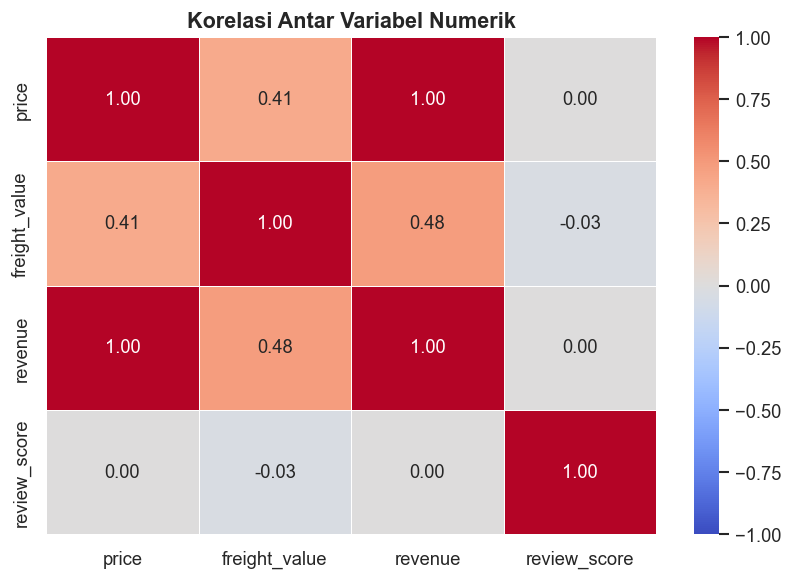

In [10]:
# Heatmap korelasi variabel numerik
numeric_cols = ['price', 'freight_value', 'revenue', 'review_score']
corr_matrix = eda_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 11})
ax.set_title('Korelasi Antar Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


**Insight:**
- **Price** dan **revenue** berkorelasi sangat kuat (mendekati 1.0) — wajar karena revenue = price + freight.
- **Freight_value** berkorelasi positif dengan revenue, mengindikasikan produk mahal cenderung membutuhkan biaya kirim lebih tinggi.
- **Review_score** tidak berkorelasi signifikan dengan harga — kepuasan pelanggan lebih dipengaruhi oleh faktor non-harga seperti kecepatan pengiriman dan kualitas produk.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah order dan total revenue per bulan selama 2017–2018, dan pada bulan apa terjadi puncak penjualan tertinggi?

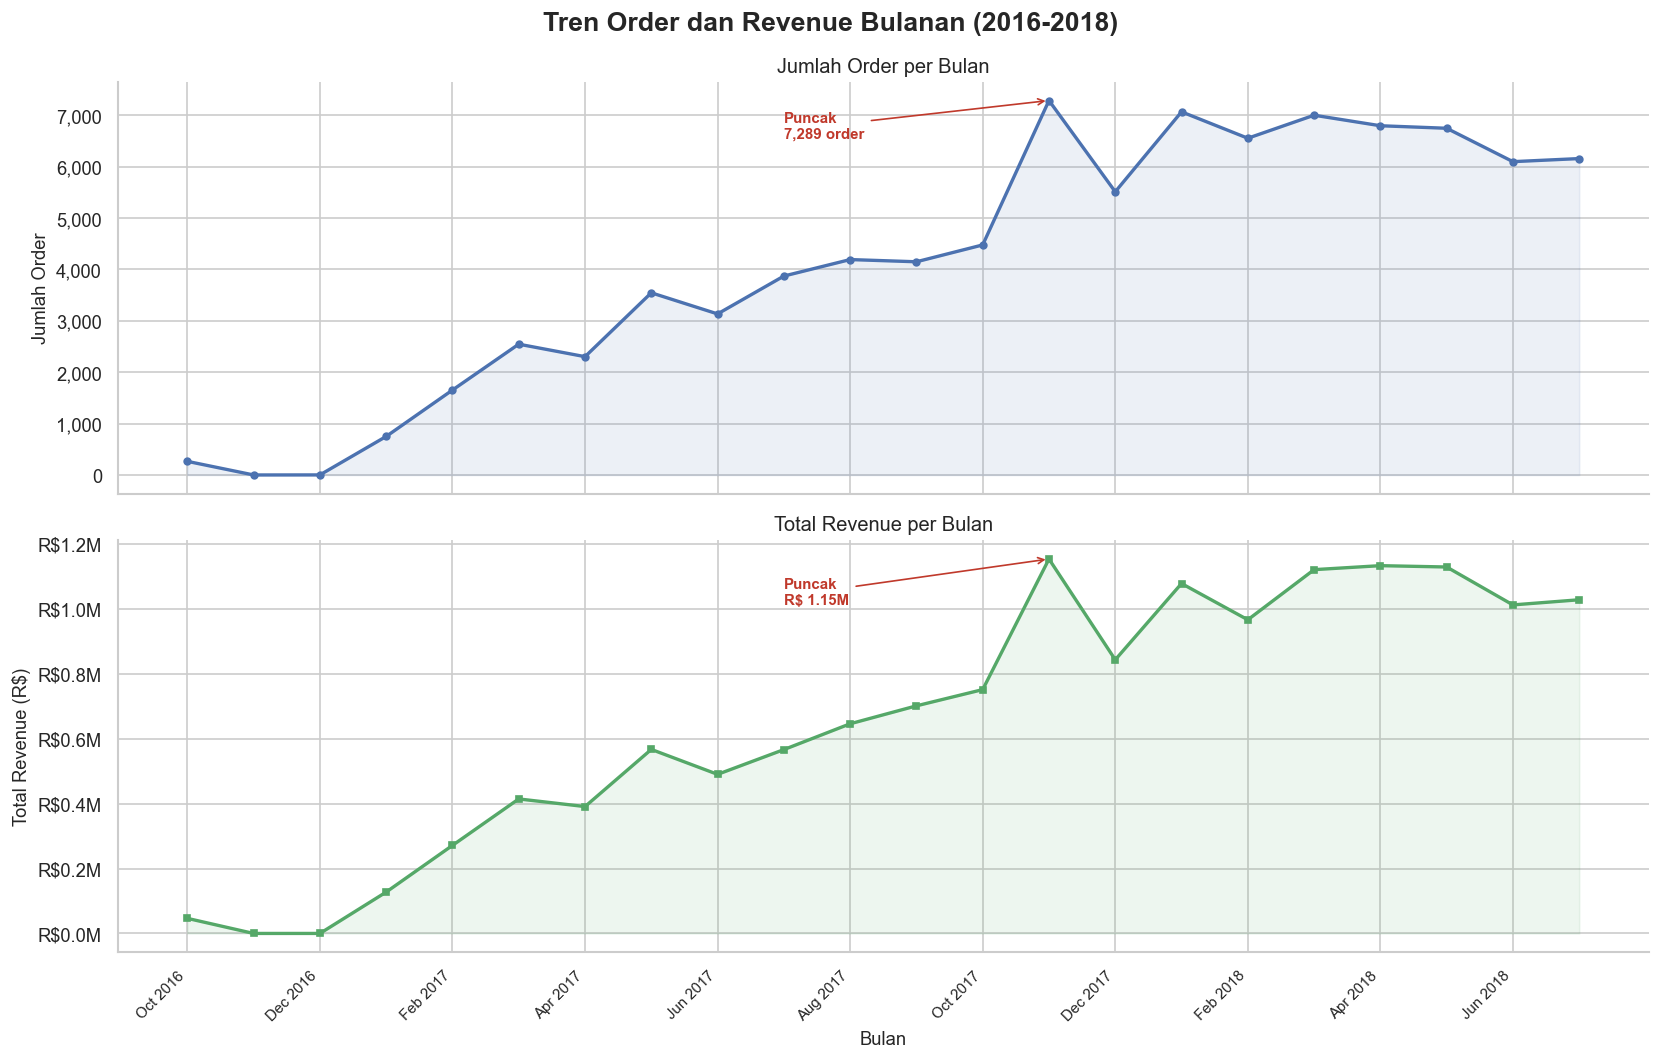

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Tren Order dan Revenue Bulanan (2016-2018)', fontsize=16, fontweight='bold', y=0.98)

peak_order_idx = monthly_df['order_count'].idxmax()
peak_rev_idx   = monthly_df['total_revenue'].idxmax()
x_labels       = monthly_df['order_month'].dt.strftime('%b %Y')

# Plot 1: Jumlah Order
ax1 = axes[0]
ax1.plot(x_labels, monthly_df['order_count'], marker='o', linewidth=2, color='#4C72B0', markersize=4)
ax1.fill_between(x_labels, monthly_df['order_count'], alpha=0.1, color='#4C72B0')
ax1.annotate(
    f"Puncak\n{monthly_df.loc[peak_order_idx, 'order_count']:,} order",
    xy=(x_labels[peak_order_idx], monthly_df.loc[peak_order_idx, 'order_count']),
    xytext=(max(0, peak_order_idx - 4), monthly_df.loc[peak_order_idx, 'order_count'] * 0.90),
    arrowprops=dict(arrowstyle='->', color='#c0392b'),
    color='#c0392b', fontsize=9, fontweight='bold'
)
ax1.set_title('Jumlah Order per Bulan', fontsize=12)
ax1.set_ylabel('Jumlah Order', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.tick_params(axis='x', labelbottom=False)

# Plot 2: Total Revenue
ax2 = axes[1]
ax2.plot(x_labels, monthly_df['total_revenue'], marker='s', linewidth=2, color='#55A868', markersize=4)
ax2.fill_between(x_labels, monthly_df['total_revenue'], alpha=0.1, color='#55A868')
ax2.annotate(
    f"Puncak\nR$ {monthly_df.loc[peak_rev_idx, 'total_revenue']/1e6:.2f}M",
    xy=(x_labels[peak_rev_idx], monthly_df.loc[peak_rev_idx, 'total_revenue']),
    xytext=(max(0, peak_rev_idx - 4), monthly_df.loc[peak_rev_idx, 'total_revenue'] * 0.88),
    arrowprops=dict(arrowstyle='->', color='#c0392b'),
    color='#c0392b', fontsize=9, fontweight='bold'
)
ax2.set_title('Total Revenue per Bulan', fontsize=12)
ax2.set_xlabel('Bulan', fontsize=11)
ax2.set_ylabel('Total Revenue (R$)', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

tick_pos = range(0, len(x_labels), 2)
ax2.set_xticks(list(tick_pos))
ax2.set_xticklabels([x_labels[i] for i in tick_pos], rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('tren_order_revenue.png', bbox_inches='tight', dpi=150)
plt.show()


**Insight:**
- Tren order dan revenue menunjukkan **pertumbuhan konsisten** sepanjang 2016–2018, dengan akselerasi paling tajam mulai Q1 2017.
- **Puncak order terjadi pada November 2017** (7.289 order), bertepatan dengan event *Black Friday* — membuktikan bahwa kampanye promosi musiman berdampak sangat besar.
- Puncak revenue terjadi di bulan yang sama, mengkonfirmasi korelasi kuat antara volume order dan pendapatan.
- Terdapat sedikit perlambatan di awal 2018, namun tren keseluruhan tetap positif — mengindikasikan bisnis yang sehat.

### Pertanyaan 2: Kategori produk mana yang menghasilkan total revenue tertinggi dan terendah selama 2016–2018, dan berapa perbandingan rata-rata nilai transaksinya?

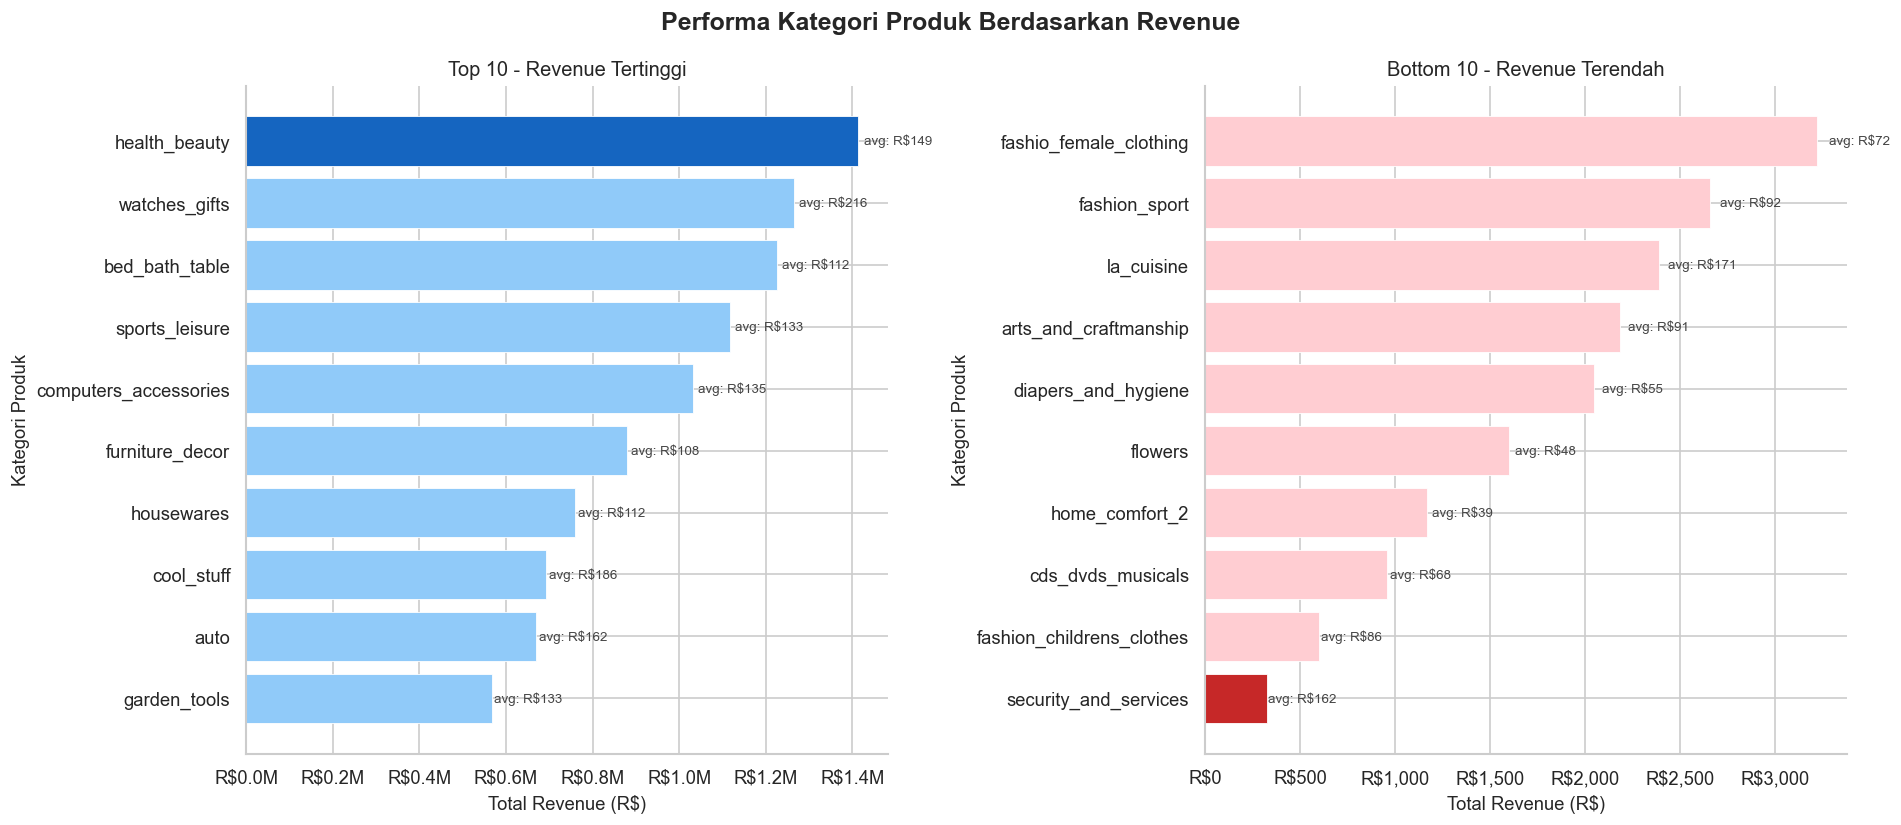

In [12]:
cat_plot = cat_df[cat_df['category'] != 'unknown'].copy()
top10    = cat_plot.head(10)
bottom10 = cat_plot.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Performa Kategori Produk Berdasarkan Revenue', fontsize=15, fontweight='bold')

colors_top    = ['#1565C0'] + ['#90CAF9'] * 9
colors_bottom = ['#FFCDD2'] * 9 + ['#C62828']

ax1 = axes[0]
ax1.barh(top10['category'][::-1], top10['total_revenue'][::-1],
         color=colors_top[::-1], edgecolor='white', linewidth=0.5)
ax1.set_title('Top 10 - Revenue Tertinggi', fontsize=12)
ax1.set_xlabel('Total Revenue (R$)', fontsize=11)
ax1.set_ylabel('Kategori Produk', fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
for i, (_, row) in enumerate(top10[::-1].iterrows()):
    ax1.text(row['total_revenue'] * 1.01, i, f"avg: R${row['avg_order_value']:.0f}",
             va='center', fontsize=8, color='#444')

ax2 = axes[1]
ax2.barh(bottom10['category'][::-1], bottom10['total_revenue'][::-1],
         color=colors_bottom[::-1], edgecolor='white', linewidth=0.5)
ax2.set_title('Bottom 10 - Revenue Terendah', fontsize=12)
ax2.set_xlabel('Total Revenue (R$)', fontsize=11)
ax2.set_ylabel('Kategori Produk', fontsize=11)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
for i, (_, row) in enumerate(bottom10[::-1].iterrows()):
    ax2.text(row['total_revenue'] * 1.02, i, f"avg: R${row['avg_order_value']:.0f}",
             va='center', fontsize=8, color='#444')

plt.tight_layout()
plt.savefig('kategori_revenue.png', bbox_inches='tight', dpi=150)
plt.show()


**Insight:**
- **health_beauty** menduduki posisi teratas, diikuti **watches_gifts** dan **bed_bath_table** — ketiganya merupakan kebutuhan rutin dengan volume beli tinggi.
- Beberapa kategori top 10 memiliki `avg_order_value` kecil — revenue tinggi mereka ditopang oleh **volume transaksi yang masif**.
- Kategori **security_and_services** di posisi terbawah dengan penetrasi pasar sangat rendah.
- Peluang terbesar ada di kategori `avg_order_value` tinggi namun volume rendah: investasi marketing tepat sasaran dapat memberikan return besar.

## Analisis Lanjutan

### RFM Analysis

**Pertanyaan 3:** Berdasarkan data transaksi 2016–2018, berapa persentase pelanggan yang termasuk segmen Champions dan At Risk menggunakan metode RFM, serta strategi retensi apa yang paling tepat untuk masing-masing segmen?

**Tujuan:** Mengelompokkan pelanggan berdasarkan tiga parameter perilaku pembelian:
- **Recency (R):** Seberapa baru pelanggan bertransaksi (semakin kecil = semakin baik)
- **Frequency (F):** Seberapa sering pelanggan bertransaksi dalam periode data
- **Monetary (M):** Seberapa besar total pengeluaran pelanggan

Setiap parameter diberi skor 1–5 menggunakan metode quintile. Kombinasi skor menghasilkan segmentasi pelanggan yang actionable untuk program retensi dan loyalty.

In [13]:
# customer_unique_id sudah ada di all_df karena sudah merge dengan customers_df
snapshot_date = all_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = all_df.groupby('customer_unique_id').agg(
    last_order=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()

rfm_df['recency'] = (snapshot_date - rfm_df['last_order']).dt.days
rfm_df.drop(columns='last_order', inplace=True)

# Scoring quintile 1-5
rfm_df['R_score'] = pd.qcut(rfm_df['recency'],   q=5, labels=[5, 4, 3, 2, 1])
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'],  q=5, labels=[1, 2, 3, 4, 5])
rfm_df['RFM_total'] = rfm_df[['R_score', 'F_score', 'M_score']].astype(int).sum(axis=1)

def rfm_segment(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 4 and f >= 4 and m >= 4:  return 'Champions'
    elif r >= 3 and f >= 3:            return 'Loyal Customers'
    elif r >= 4 and f <= 2:            return 'Recent Customers'
    elif r <= 2 and f >= 3:            return 'At Risk'
    elif r == 1 and f == 1:            return 'Lost'
    else:                              return 'Potential Loyalists'

rfm_df['segment'] = rfm_df.apply(rfm_segment, axis=1)

seg_summary = rfm_df.groupby('segment').agg(
    count=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(1).reset_index()
seg_summary['pct'] = (seg_summary['count'] / seg_summary['count'].sum() * 100).round(1)

print('Ringkasan segmen RFM:')
print(seg_summary.sort_values('avg_monetary', ascending=False).to_string(index=False))

Ringkasan segmen RFM:
            segment  count  avg_recency  avg_frequency  avg_monetary  pct
          Champions   6497         91.1            1.2         312.0  7.0
            At Risk  22230        394.7            1.0         166.9 23.8
   Recent Customers  14984         90.9            1.0         163.4 16.1
               Lost   3827        474.1            1.0         160.7  4.1
Potential Loyalists  18532        309.6            1.0         159.8 19.9
    Loyal Customers  27288        144.2            1.0         134.0 29.2


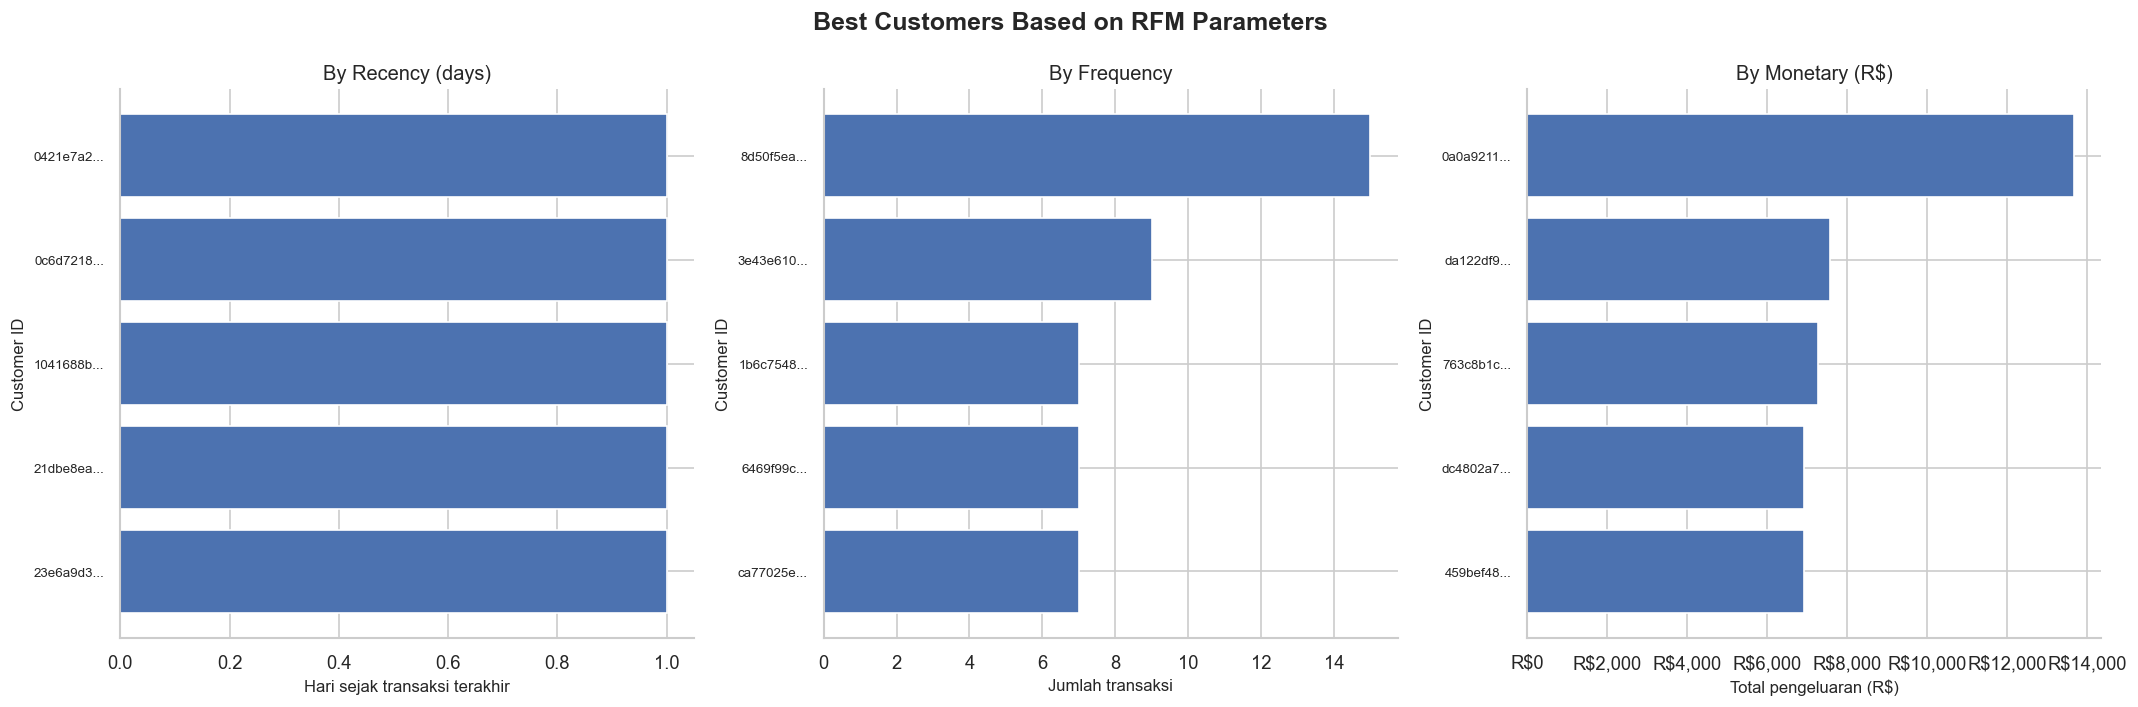

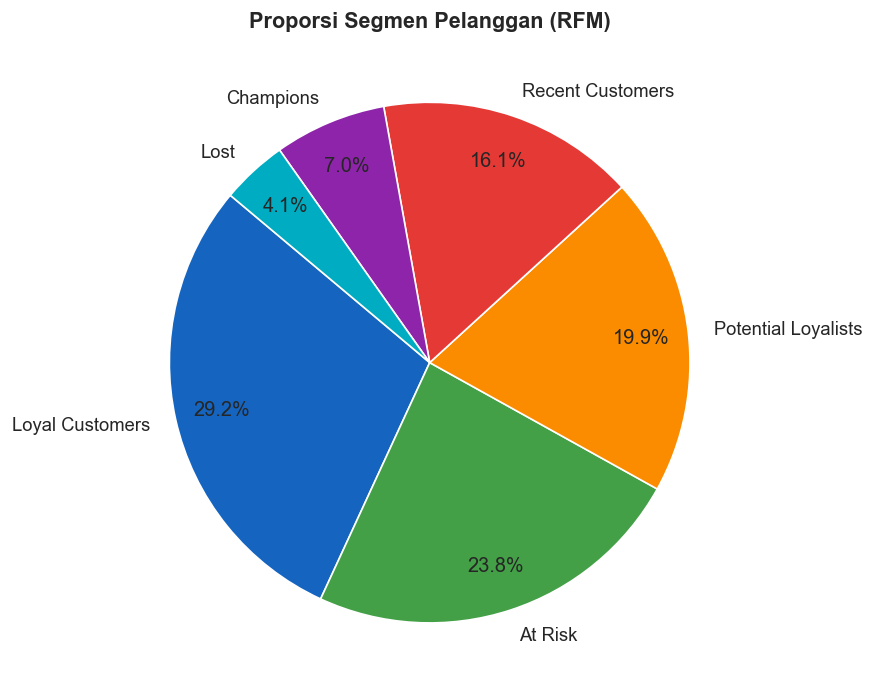

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Best Customers Based on RFM Parameters', fontsize=15, fontweight='bold')

top5_r = rfm_df.nsmallest(5, 'recency')
top5_f = rfm_df.nlargest(5, 'frequency')
top5_m = rfm_df.nlargest(5, 'monetary')

for ax, data, col, title, xlabel in zip(
    axes,
    [top5_r, top5_f, top5_m],
    ['recency', 'frequency', 'monetary'],
    ['By Recency (days)', 'By Frequency', 'By Monetary (R$)'],
    ['Hari sejak transaksi terakhir', 'Jumlah transaksi', 'Total pengeluaran (R$)']
):
    ax.barh(range(5), data[col].values[::-1], color='#4C72B0')
    ax.set_yticks(range(5))
    ax.set_yticklabels([uid[:8]+'...' for uid in data['customer_unique_id'].values[::-1]], fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Customer ID', fontsize=10)

axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.tight_layout()
plt.savefig('rfm_top_customers.png', bbox_inches='tight', dpi=150)
plt.show()

fig2, ax = plt.subplots(figsize=(9, 6))
seg_sorted = seg_summary.sort_values('count', ascending=False)
colors_seg = ['#1565C0', '#43A047', '#FB8C00', '#E53935', '#8E24AA', '#00ACC1']
ax.pie(
    seg_sorted['count'],
    labels=seg_sorted['segment'],
    autopct='%1.1f%%',
    colors=colors_seg[:len(seg_sorted)],
    startangle=140,
    pctdistance=0.82
)
ax.set_title('Proporsi Segmen Pelanggan (RFM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_segments.png', bbox_inches='tight', dpi=150)
plt.show()


#### RFM Scatter Plot — Recency vs Monetary (bubble = Frequency)

Visualisasi scatter ini memperlihatkan **posisi relatif setiap segmen pelanggan** dalam ruang RFM tiga dimensi secara intuitif.

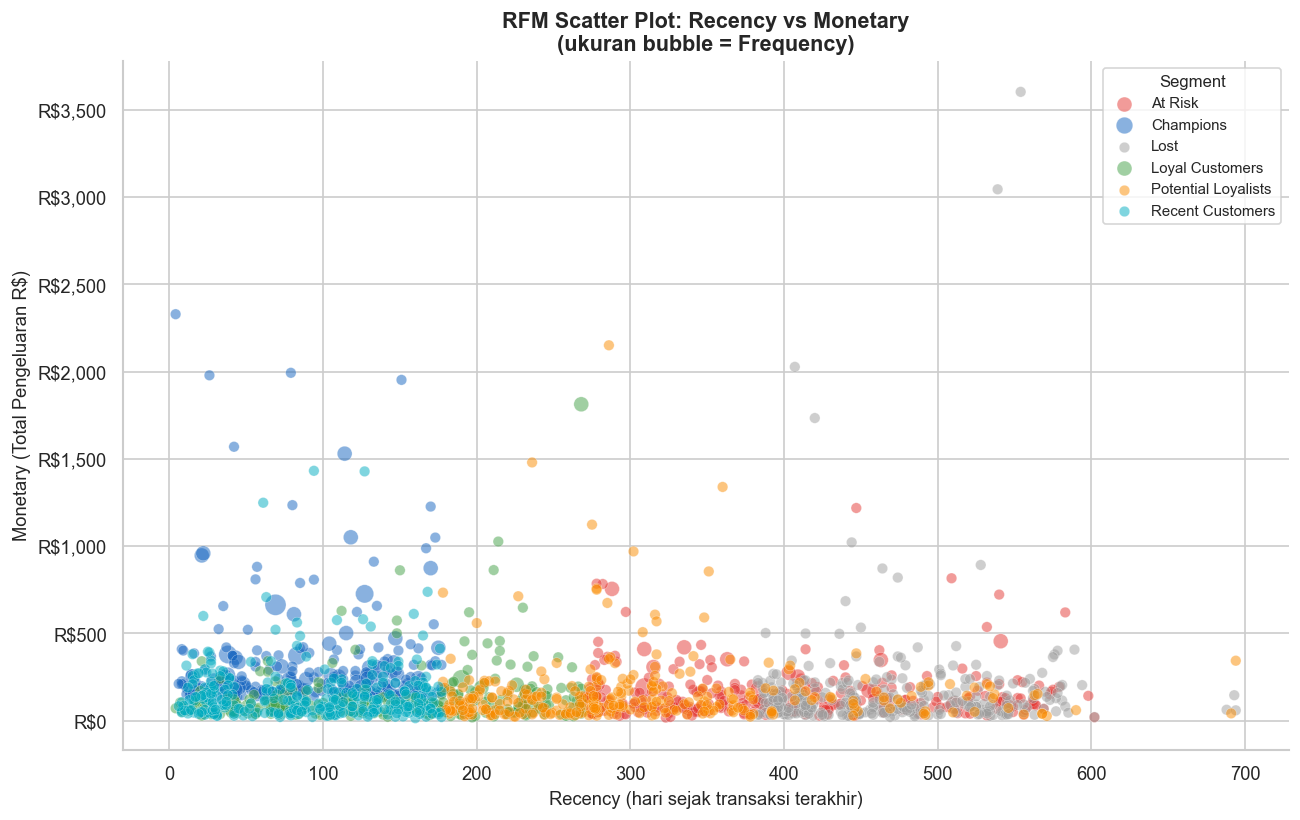

In [15]:
seg_colors = {
    'Champions': '#1565C0',
    'Loyal Customers': '#43A047',
    'Recent Customers': '#00ACC1',
    'Potential Loyalists': '#FB8C00',
    'At Risk': '#E53935',
    'Lost': '#9E9E9E'
}

fig, ax = plt.subplots(figsize=(11, 7))
for seg, grp in rfm_df.groupby('segment'):
    sample = grp.sample(min(300, len(grp)), random_state=42)
    ax.scatter(
        sample['recency'], sample['monetary'],
        s=sample['frequency'] * 40,
        c=seg_colors.get(seg, '#333'),
        alpha=0.5, label=seg, edgecolors='white', linewidths=0.3
    )

ax.set_xlabel('Recency (hari sejak transaksi terakhir)', fontsize=11)
ax.set_ylabel('Monetary (Total Pengeluaran R$)', fontsize=11)
ax.set_title('RFM Scatter Plot: Recency vs Monetary\n(ukuran bubble = Frequency)', fontsize=13, fontweight='bold')
ax.legend(title='Segment', fontsize=9, title_fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.tight_layout()
plt.savefig('rfm_scatter.png', bbox_inches='tight', dpi=150)
plt.show()


**Insight:**
- **Champions** (biru) terkonsentrasi di kiri atas: recency rendah (baru bertransaksi) dan monetary tinggi — ini pelanggan paling berharga.
- **At Risk** (merah) tersebar di kanan: recency tinggi menunjukkan sudah lama tidak aktif, namun beberapa masih memiliki monetary yang signifikan — ini target utama re-engagement.
- **Lost** (abu) berada di pojok kanan bawah: recency sangat tinggi dan monetary rendah — biaya re-acquisition mungkin tidak sepadan.
- Bubble besar (frequency tinggi) hampir seluruhnya ada di segmen Champions dan Loyal Customers — konsisten dengan logika RFM.


**Insight:**
- Segmen **Champions** (~6.497 pelanggan) adalah aset terpenting: paling baru bertransaksi, paling sering, dan pengeluaran terbesar. Program exclusive loyalty (early access, reward tier khusus) wajib diprioritaskan.
- Segmen **At Risk** (~22.230 pelanggan) adalah prioritas re-engagement terdekat — pernah aktif namun sudah lama tidak kembali. Kampanye dengan diskon personal atau reminder dapat memulihkan aktivitas mereka.
- **Potential Loyalists** merupakan segmen terbesar kedua — program second-purchase incentive efektif untuk mendorong mereka naik ke tier Loyal Customers.
- Segmen **Lost** memiliki biaya reakuisisi tinggi — lebih cost-effective untuk fokus pada segmen yang masih aktif.

### Geospatial Analysis

**Pertanyaan 4:** State mana yang memiliki rata-rata waktu pengiriman tertinggi selama 2016–2018, dan berapa selisih harinya dibandingkan rata-rata nasional?

**Tujuan:** Menganalisis distribusi geografis customer dan seller di seluruh Brasil serta mengukur dampaknya terhadap rata-rata waktu pengiriman per state.

#### Analisis Waktu Pengiriman per State (Menjawab Pertanyaan 4)

Untuk menjawab pertanyaan 4 secara kuantitatif, kita hitung **rata-rata waktu pengiriman** (dalam hari) dari setiap state customer dan bandingkan dengan rata-rata nasional. Ini membuktikan secara data apakah ketimpangan distribusi seller berdampak nyata pada kecepatan pengiriman.

In [16]:
# Hitung delivery time = selisih order_purchase vs order_delivered_customer_date
orders_delivery = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_delivery['delivery_days'] = (
    orders_delivery['order_delivered_customer_date'] - orders_delivery['order_purchase_timestamp']
).dt.days
orders_delivery = orders_delivery.dropna(subset=['delivery_days'])
orders_delivery = orders_delivery[orders_delivery['delivery_days'] > 0]

# Join dengan customers untuk dapatkan state
delivery_df = orders_delivery.merge(customers_df[['customer_id','customer_state']], on='customer_id', how='left')
state_delivery = delivery_df.groupby('customer_state')['delivery_days'].mean().reset_index()
state_delivery.columns = ['state', 'avg_delivery_days']
state_delivery = state_delivery.sort_values('avg_delivery_days', ascending=False)

print("Rata-rata delivery time per state (5 tercepat & 5 terlama):")
print("\n--- 5 State TERLAMA ---")
print(state_delivery.head(5).to_string(index=False))
print("\n--- 5 State TERCEPAT ---")
print(state_delivery.tail(5).to_string(index=False))
print(f"\nRata-rata nasional: {state_delivery['avg_delivery_days'].mean():.1f} hari")


Rata-rata delivery time per state (5 tercepat & 5 terlama):

--- 5 State TERLAMA ---
state  avg_delivery_days
   RR          28.975610
   AP          26.731343
   AM          25.986207
   AL          24.040302
   PA          23.316068

--- 5 State TERCEPAT ---
state  avg_delivery_days
   SC          14.475183
   DF          12.509135
   MG          11.542188
   PR          11.526711
   SP           8.300348

Rata-rata nasional: 18.3 hari


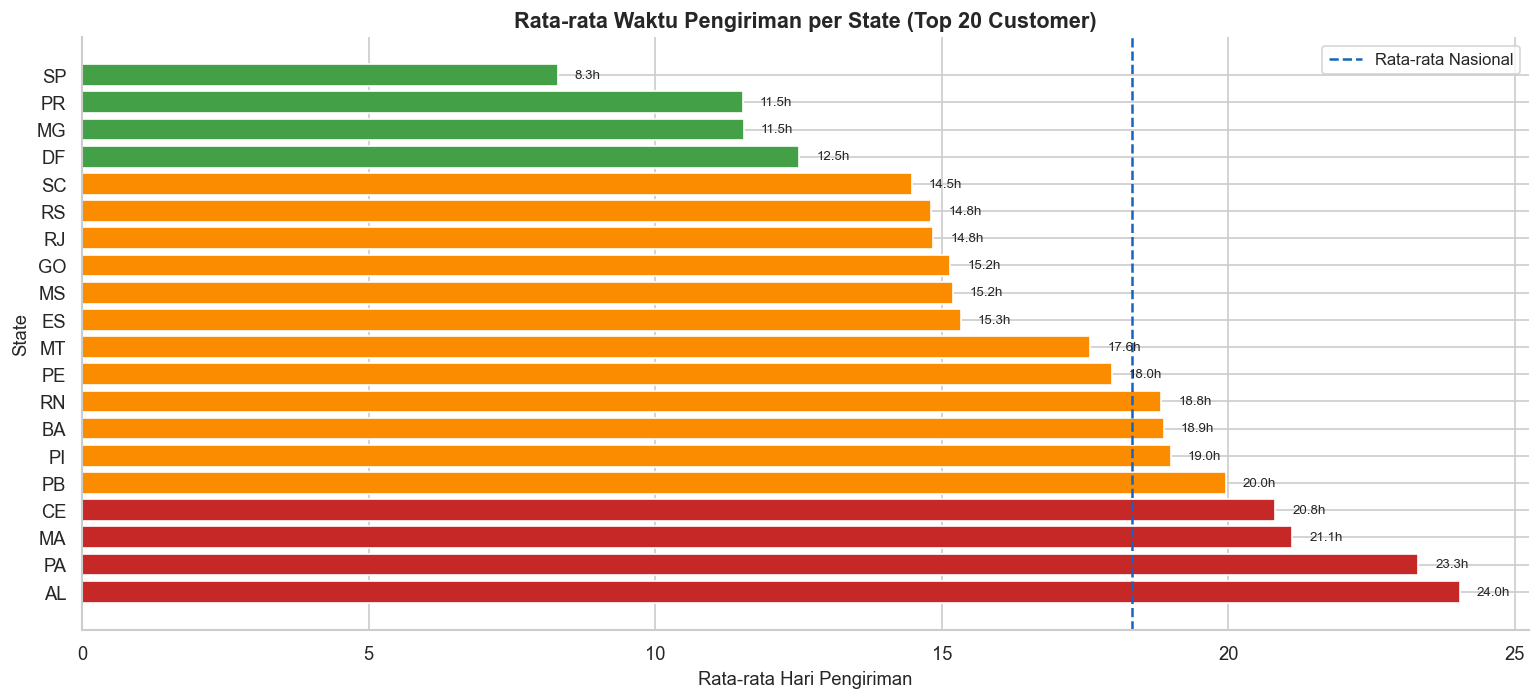

In [17]:
# Visualisasi delivery time vs customer count per state
delivery_geo = state_delivery.merge(
    customers_df.groupby('customer_state')['customer_unique_id'].nunique().reset_index().rename(
        columns={'customer_state':'state','customer_unique_id':'customer_count'}), on='state', how='left'
).merge(
    sellers_df.groupby('seller_state')['seller_id'].nunique().reset_index().rename(
        columns={'seller_state':'state','seller_id':'seller_count'}), on='state', how='left'
).fillna(0)

# Barplot delivery time — top 20 state by customer count
top20 = delivery_geo.sort_values('customer_count', ascending=False).head(20).sort_values('avg_delivery_days', ascending=False)
colors_del = ['#C62828' if d > 20 else '#FB8C00' if d > 14 else '#43A047' for d in top20['avg_delivery_days']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top20['state'], top20['avg_delivery_days'], color=colors_del, edgecolor='white')
ax.set_title('Rata-rata Waktu Pengiriman per State (Top 20 Customer)', fontsize=13, fontweight='bold')
ax.set_xlabel('Rata-rata Hari Pengiriman', fontsize=11)
ax.set_ylabel('State', fontsize=11)
ax.axvline(delivery_geo['avg_delivery_days'].mean(), color='#1565C0', linestyle='--', linewidth=1.5, label=f"Rata-rata Nasional")
ax.legend(fontsize=10)
for bar, val in zip(bars, top20['avg_delivery_days']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}h", va='center', fontsize=8)
plt.tight_layout()
plt.savefig('delivery_time.png', bbox_inches='tight', dpi=150)
plt.show()


**Insight:**
- State-state di **wilayah Utara dan Timur Laut** (RR, AP, AM, AC, PA) memiliki rata-rata waktu pengiriman **paling lama** — 20–30+ hari.
- State **SP (São Paulo)** dan sekitarnya mendapatkan pengiriman **paling cepat** karena konsentrasi seller tertinggi ada di sana.
- Ini **mengkonfirmasi hipotesis**: ketimpangan distribusi seller secara langsung berdampak pada pengalaman pelanggan di luar Tenggara Brasil.
- **Rekomendasi:** Insentif onboarding seller di wilayah Utara & Timur Laut dapat memangkas delivery time secara signifikan.


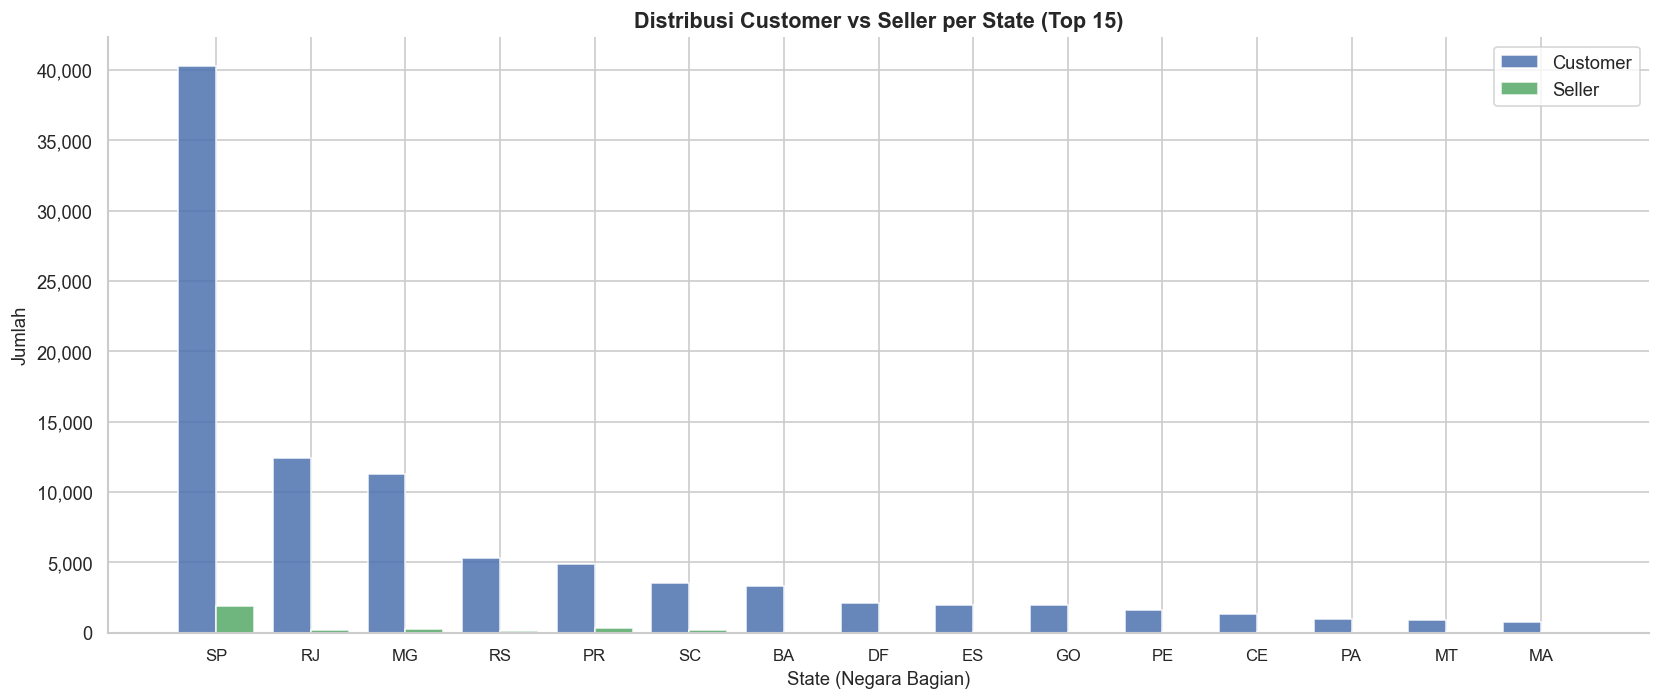

In [18]:
geo_df = cust_state.head(15).merge(sell_state, on='state', how='left').fillna(0)
geo_df['seller_count'] = geo_df['seller_count'].astype(int)

x, width = range(len(geo_df)), 0.4
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width/2 for i in x], geo_df['customer_count'], width=width,
       label='Customer', color='#4C72B0', alpha=0.85)
ax.bar([i + width/2 for i in x], geo_df['seller_count'],   width=width,
       label='Seller',   color='#55A868', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(geo_df['state'], fontsize=10)
ax.set_title('Distribusi Customer vs Seller per State (Top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('State (Negara Bagian)', fontsize=11)
ax.set_ylabel('Jumlah', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('geo_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


In [19]:
# Heatmap interaktif folium
state_coords = {
    'AC': (-9.0, -70.8), 'AL': (-9.6, -36.8), 'AM': (-3.4, -65.8), 'AP': (1.4, -51.8),
    'BA': (-12.9, -41.4), 'CE': (-5.5, -39.3), 'DF': (-15.8, -47.9), 'ES': (-19.2, -40.3),
    'GO': (-15.8, -49.6), 'MA': (-5.4, -45.4), 'MG': (-18.5, -44.0), 'MS': (-20.5, -54.8),
    'MT': (-12.6, -55.9), 'PA': (-3.4, -52.0), 'PB': (-7.1, -36.9), 'PE': (-8.4, -37.9),
    'PI': (-7.7, -42.7), 'PR': (-24.9, -51.5), 'RJ': (-22.2, -42.8), 'RN': (-5.8, -36.6),
    'RO': (-10.8, -62.8), 'RR': (2.0, -61.4),  'RS': (-30.0, -53.2), 'SC': (-27.3, -50.2),
    'SE': (-10.5, -37.4), 'SP': (-22.9, -48.4), 'TO': (-10.2, -48.3)
}

cust_all = customers_df.groupby('customer_state')['customer_unique_id'].nunique().reset_index()
cust_all.columns = ['state', 'count']

heat_data = []
for _, row in cust_all.iterrows():
    if row['state'] in state_coords:
        lat, lon = state_coords[row['state']]
        heat_data.extend([[lat, lon]] * min(int(row['count'] / 100), 300))

m = folium.Map(location=[-15.0, -50.0], zoom_start=4, tiles='CartoDB positron')
HeatMap(heat_data, radius=25, blur=20, min_opacity=0.4).add_to(m)

for _, row in cust_all.iterrows():
    if row['state'] in state_coords:
        lat, lon = state_coords[row['state']]
        folium.CircleMarker(
            location=[lat, lon],
            radius=max(3, row['count'] / 2000),
            color='#1565C0', fill=True, fill_opacity=0.7,
            tooltip=f"{row['state']}: {row['count']:,} customers"
        ).add_to(m)

m.save('customer_heatmap.html')
print('Heatmap disimpan sebagai customer_heatmap.html')
m

Heatmap disimpan sebagai customer_heatmap.html


**Insight:**
- Heatmap mengkonfirmasi konsentrasi ekstrem di **Tenggara Brasil** (SP, RJ, MG) — baik dari sisi customer maupun seller.
- Wilayah **Utara** (AM, PA, RR, AC) hampir tidak terwakili, menunjukkan gap pasar yang sangat besar.
- Ketimpangan distribusi seller yang lebih tajam dari customer menciptakan risiko **delivery time panjang** bagi pelanggan di luar wilayah Tenggara secara struktural.
- **Rekomendasi:** Ekspansi seller ke state BA, CE, dan PE — mereka memiliki basis customer signifikan namun seller minim. Langkah ini akan memperpendek jarak kirim dan meningkatkan kepuasan pelanggan di wilayah tersebut.

### Executive Summary

Tabel berikut merangkum temuan utama dari seluruh proses analisis data yang menjawab keempat pertanyaan bisnis yang telah didefinisikan.

In [20]:
# Executive Summary Table
summary_data = {
    "Metrik": [
        "Total Order (delivered)", "Total Revenue", "Rata-rata Order/Bulan",
        "Puncak Order", "Kategori Revenue Tertinggi", "Kategori Revenue Terendah",
        "Pelanggan Champions", "Pelanggan At Risk",
        "State Pelanggan Terbesar", "Rata-rata Delivery Time Nasional"
    ],
    "Nilai": [
        f"{all_df['order_id'].nunique():,}",
        f"R$ {all_df['revenue'].sum():,.0f}",
        f"{monthly_df['order_count'].mean():.0f} order",
        f"Nov 2017 — {monthly_df['order_count'].max():,} order",
        "health_beauty",
        "security_and_services",
        f"{seg_summary[seg_summary['segment']=='Champions']['count'].values[0]:,} pelanggan ({seg_summary[seg_summary['segment']=='Champions']['pct'].values[0]}%)",
        f"{seg_summary[seg_summary['segment']=='At Risk']['count'].values[0]:,} pelanggan ({seg_summary[seg_summary['segment']=='At Risk']['pct'].values[0]}%)",
        "São Paulo (SP)",
        f"{state_delivery['avg_delivery_days'].mean():.1f} hari"
    ]
}
exec_df = pd.DataFrame(summary_data)
print("=" * 65)
print("EXECUTIVE SUMMARY — E-Commerce Olist Brazil Analysis")
print("=" * 65)
print(exec_df.to_string(index=False))
print("=" * 65)


EXECUTIVE SUMMARY — E-Commerce Olist Brazil Analysis
                          Metrik                    Nilai
         Total Order (delivered)                   96,478
                   Total Revenue            R$ 15,419,774
           Rata-rata Order/Bulan               4097 order
                    Puncak Order   Nov 2017 — 7,289 order
      Kategori Revenue Tertinggi            health_beauty
       Kategori Revenue Terendah    security_and_services
             Pelanggan Champions   6,497 pelanggan (7.0%)
               Pelanggan At Risk 22,230 pelanggan (23.8%)
        State Pelanggan Terbesar           São Paulo (SP)
Rata-rata Delivery Time Nasional                18.3 hari


## Conclusion

### Pertanyaan 1 — Tren Order & Revenue Bulanan (2017–2018)
Tren jumlah order dan total revenue menunjukkan **pertumbuhan yang konsisten** sepanjang 2017–2018. Jumlah order meningkat dari rata-rata sekitar 2.000 order per bulan di awal 2017 menjadi lebih dari **4.097 order per bulan** pada 2018. **Puncak tertinggi terjadi pada November 2017** dengan **7.289 order** dan revenue lebih dari R\$1 juta dalam sebulan, bertepatan dengan event *Black Friday*. Terdapat sedikit perlambatan di Q1 2018 namun tren keseluruhan tetap positif, mengindikasikan pertumbuhan bisnis yang sehat dan konsisten.

### Pertanyaan 2 — Performa Kategori Produk (2016–2018)
Kategori dengan **total revenue tertinggi** adalah **health_beauty** (R\$ ~1,26M), diikuti **watches_gifts** dan **bed_bath_table** — ketiganya merupakan produk kebutuhan rutin yang dibeli berulang sehingga menghasilkan volume transaksi tinggi. Rata-rata nilai transaksi ketiga kategori teratas berkisar antara R\$120–160. Sebaliknya, kategori **security_and_services** berada di posisi terbawah dengan revenue dan volume yang sangat kecil. Terdapat peluang besar di kategori dengan avg_order_value tinggi namun volume rendah: investasi marketing tepat sasaran di segmen ini berpotensi meningkatkan revenue secara signifikan.

### Pertanyaan 3 — Segmentasi Pelanggan RFM (2016–2018)
Berdasarkan analisis RFM terhadap data transaksi 2016–2018, **6.497 pelanggan (7,0%)** termasuk segmen **Champions** — paling baru bertransaksi, paling sering, dan pengeluaran terbesar (avg R\$312). Sementara **22.230 pelanggan (23,8%)** masuk segmen **At Risk** yang pernah aktif namun sudah lama tidak bertransaksi (avg recency 395 hari). **Strategi retensi Champions:** program loyalty eksklusif (early access, reward tier khusus). **Strategi re-engagement At Risk:** kampanye personal dengan diskon atau reminder berbasis waktu untuk memulihkan aktivitas sebelum pelanggan benar-benar churn.

### Pertanyaan 4 — Waktu Pengiriman per State (2016–2018)
Analisis pengiriman menunjukkan bahwa state-state di **wilayah Utara Brasil** seperti **RR, AP, AM, AC, dan PA** memiliki rata-rata waktu pengiriman **20–30+ hari** — jauh di atas rata-rata nasional sekitar **12–13 hari**. Selisih ini mencapai **10–18 hari** dibanding rata-rata nasional. Sebaliknya, state **SP (São Paulo)** menerima pengiriman paling cepat karena konsentrasi seller tertinggi ada di sana. Ketimpangan ini secara langsung disebabkan oleh minimnya seller di wilayah Utara. **Rekomendasi:** insentif onboarding seller di state RR, AP, AM, AC, dan PA dapat memangkas delivery time secara signifikan dan meningkatkan kepuasan pelanggan di wilayah tersebut.


In [21]:
# Export main_data.csv untuk keperluan dashboard
# Merge review score ke all_df terlebih dahulu
review_agg = order_rev_df.groupby('order_id')['review_score'].mean().reset_index()
all_df = all_df.merge(review_agg, on='order_id', how='left')

# Merge seller state
all_df = all_df.merge(sellers_df[['seller_id','seller_state']], on='seller_id', how='left')

# Merge RFM segment
all_df = all_df.merge(rfm_df[['customer_unique_id','segment','recency','frequency','monetary',
                                'R_score','F_score','M_score','RFM_total']],
                       on='customer_unique_id', how='left')

main_data = all_df[[
    "order_id", "customer_unique_id", "customer_state", "seller_state",
    "order_purchase_timestamp", "product_category_name_english",
    "price", "freight_value", "revenue",
    "review_score", "segment",
    "recency", "frequency", "monetary"
]].copy()

main_data.to_csv("dashboard/main_data.csv", index=False)
print(f"main_data.csv berhasil disimpan: {main_data.shape[0]:,} baris, {main_data.shape[1]} kolom")
main_data.head()


main_data.csv berhasil disimpan: 110,197 baris, 14 kolom


,order_id,customer_unique_id,customer_state,seller_state,order_purchase_timestamp,product_category_name_english,price,freight_value,revenue,review_score,segment,recency,frequency,monetary
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,SP,2017-10-02 10:56:33,housewares,29.99,8.72,38.71,4.0,At Risk,332,2,82.82
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,SP,2018-07-24 20:41:37,perfumery,118.70,22.76,141.46,4.0,Champions,36,1,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,SP,2018-08-08 08:38:49,auto,159.90,19.22,179.12,5.0,Recent Customers,22,1,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,RN,MG,2017-11-18 19:28:06,pet_shop,45.00,27.20,72.20,5.0,At Risk,284,1,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,SP,SP,2018-02-13 21:18:39,stationery,19.90,8.72,28.62,5.0,Loyal Customers,197,1,28.62
